In [28]:
import numpy as np
from itertools import combinations
import os

In [29]:
import matplotlib.pyplot as plt

In [30]:
from matplotlib import colors
%matplotlib inline

In [31]:
import pandas as pd
import numpy as np
from multiprocessing import Pool

In [32]:
import bioframe
import cooler
import cooltools

In [33]:
resolution = 100
wildtype = cooler.Cooler('<filename>::/resolutions/'+str(resolution))

In [36]:
#loading the chromosome size file
chromsizes = pd.read_csv(<path to chromsizes file>)
chromsizes.head()

,chrom,start,end,name
0,III,2400,1070904,3l
1,III,1137003,2440000,3r
2,II,0,1602264,2l
3,II,1644747,4539804,2r
4,I,0,3753687,1l


In [37]:
chromsizes
bioframe.core.checks.is_viewframe(chromsizes)

True

In [38]:
#this is calculating the smoothed curves for everything
cvd = cooltools.expected_cis(
    clr=<cooler name 1>,
    view_df=chromsizes,
    smooth=True,
    aggregate_smoothed=True,
    smooth_sigma=0.1,
    nproc=1
)

cvd2 = cooltools.expected_cis(
    clr=<cooler name 2>,
    view_df=chromsizes,
    smooth=True,
    aggregate_smoothed=True,
    smooth_sigma=0.1,
    nproc=1
)
cvd4 = cooltools.expected_cis(
    clr=<cooler name 3>,
    view_df=chromsizes,
    smooth=True,
    aggregate_smoothed=True,
    smooth_sigma=0.1,
    nproc=1
)
cvd5 = cooltools.expected_cis(
    clr=<cooler name 3>,
    view_df=chromsizes,
    smooth=True,
    aggregate_smoothed=True,
    smooth_sigma=0.1,
    nproc=1
)

INFO:root:fallback to serial implementation.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
INFO:root:fallback to serial implementation.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
INFO:root:fallback to serial implementation.
/Library/Frameworks/Python.framework/Versions/3

In [39]:
#display data from above
display(cvd.head(4))
display(cvd.tail(4))



,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg,balanced.avg.smoothed,balanced.avg.smoothed.agg
0,3l,3l,0,0,NaN,10686,10564,NaN,NaN,NaN,NaN,NaN,NaN
1,3l,3l,1,100,0.001647,10685,10473,NaN,NaN,NaN,NaN,0.001601,0.001647
2,3l,3l,2,200,0.129925,10684,10456,263627.0,1572.777830,24.674934,0.150419,0.126390,0.129925
3,3l,3l,3,300,0.035443,10683,10454,59120.0,269.834199,5.534026,0.025812,0.034801,0.035443


,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg,balanced.avg.smoothed,balanced.avg.smoothed.agg
124122,1r,1r,17894,1789400,0.000002,4,4,0.0,0.0,0.0,0.0,0.000002,0.000002
124123,1r,1r,17895,1789500,0.000002,3,3,0.0,0.0,0.0,0.0,0.000002,0.000002
124124,1r,1r,17896,1789600,0.000002,2,2,0.0,0.0,0.0,0.0,0.000002,0.000002
124125,1r,1r,17897,1789700,0.000002,1,1,0.0,0.0,0.0,0.0,0.000002,0.000002


/var/folders/s2/hs20041x1zj74pw6m63dbtd40000gr/T/ipykernel_43207/2330236636.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  cvd['balanced.avg.smoothed'].loc[cvd['dist'] < 2] = np.nan
/var/folders/s2/hs20041x1zj74pw6m63dbtd40000gr/T/ipyke

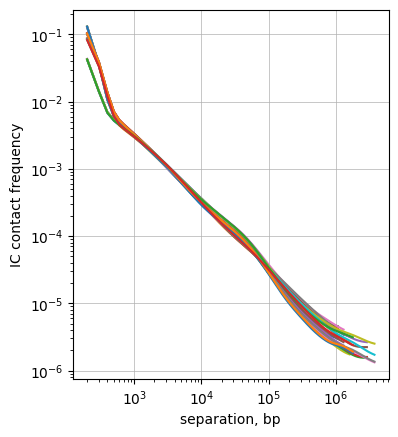

In [40]:
#plotting it
cvd['balanced.avg.smoothed'].loc[cvd['dist'] < 2] = np.nan
cvd2['balanced.avg.smoothed'].loc[cvd2['dist'] < 2] = np.nan
cvd4['balanced.avg.smoothed'].loc[cvd4['dist'] < 2] = np.nan
cvd5['balanced.avg.smoothed'].loc[cvd5['dist'] < 2] = np.nan

f, ax = plt.subplots(1,1)

for region in chromsizes['name']:
    ax.loglog(
        cvd['dist_bp'].loc[cvd['region1']==region],
        cvd['balanced.avg.smoothed'].loc[cvd['region1']==region],
        cvd2['dist_bp'].loc[cvd2['region1']==region],
        cvd2['balanced.avg.smoothed'].loc[cvd2['region1']==region],
        cvd4['dist_bp'].loc[cvd4['region1']==region],
        cvd4['balanced.avg.smoothed'].loc[cvd4['region1']==region],
        cvd5['dist_bp'].loc[cvd5['region1']==region],
        cvd5['balanced.avg.smoothed'].loc[cvd5['region1']==region],
    )
    ax.set(
        xlabel='separation, bp',
        ylabel='IC contact frequency')
    ax.set_aspect(1.0)
    ax.grid(lw=0.5)


In [41]:
#calculate the derivatives
cvd_merged = cvd.drop_duplicates(subset=['dist'])[['dist_bp', 'balanced.avg.smoothed.agg']]
cvd2_merged = cvd2.drop_duplicates(subset=['dist'])[['dist_bp', 'balanced.avg.smoothed.agg']]
cvd3_merged = cvd4.drop_duplicates(subset=['dist'])[['dist_bp', 'balanced.avg.smoothed.agg']]
cvd4_merged = cvd5.drop_duplicates(subset=['dist'])[['dist_bp', 'balanced.avg.smoothed.agg']]

In [42]:
#calculate the derivatives
der = np.gradient(np.log(cvd_merged['balanced.avg.smoothed.agg']),
                  np.log(cvd_merged['dist_bp']))
der2 = np.gradient(np.log(cvd2_merged['balanced.avg.smoothed.agg']),
                  np.log(cvd2_merged['dist_bp']))
der3 = np.gradient(np.log(cvd4_merged['balanced.avg.smoothed.agg']),
                  np.log(cvd4_merged['dist_bp']))
der4 = np.gradient(np.log(cvd5_merged['balanced.avg.smoothed.agg']),
                  np.log(cvd5_merged['dist_bp']))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/function_base.py:1243: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/function_base.py:1244: RuntimeWarning: invalid value encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))


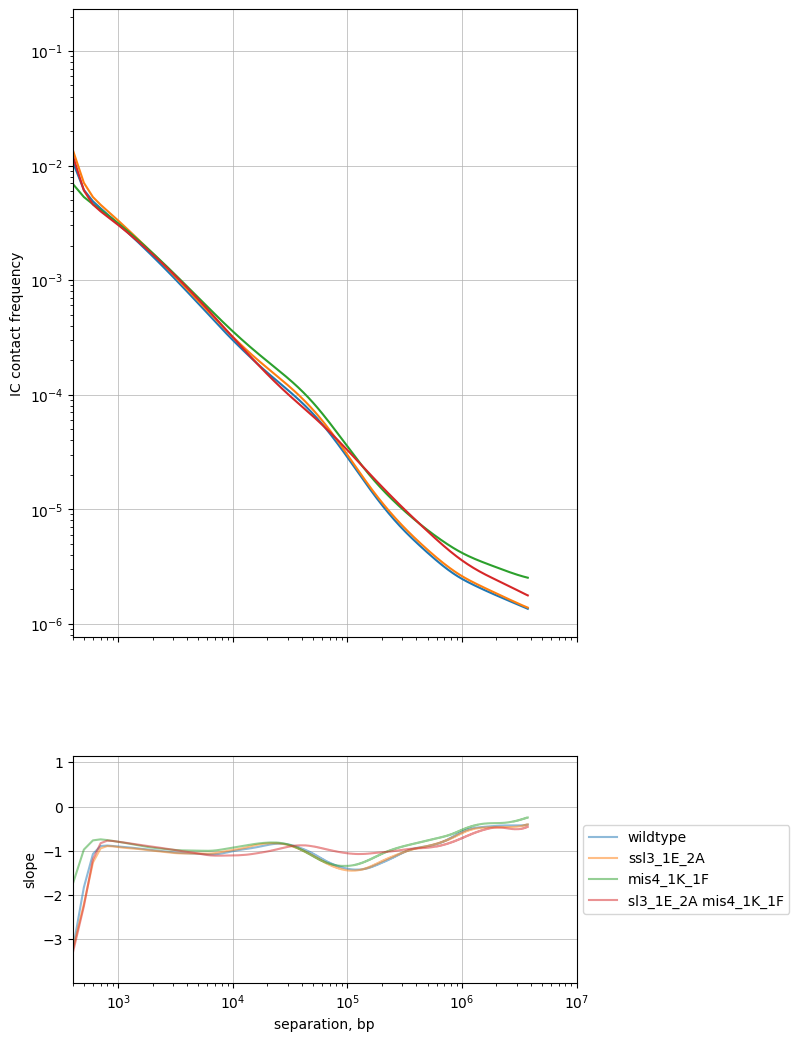

In [43]:
f, axs = plt.subplots(
    figsize=(6.5,13),
    nrows=2,
    gridspec_kw={'height_ratios':[6,2]},
    sharex=True)
ax = axs[0]
ax.loglog(
    cvd_merged['dist_bp'],
    cvd_merged['balanced.avg.smoothed.agg'],
    cvd2_merged['dist_bp'],
    cvd2_merged['balanced.avg.smoothed.agg'],
    cvd4_merged['dist_bp'],
    cvd4_merged['balanced.avg.smoothed.agg'],
    cvd5_merged['dist_bp'],
    cvd5_merged['balanced.avg.smoothed.agg'],
    '-'
)

ax.set(
    ylabel='IC contact frequency',
    xlim=(4e2,1e7)
)
ax.set_aspect(1.0)
ax.grid(lw=0.5)


ax = axs[1]
ax.semilogx(
    cvd_merged['dist_bp'],
    der,
    cvd2_merged['dist_bp'],
    der2,
    cvd4_merged['dist_bp'],
    der4,
    cvd5_merged['dist_bp'],
    der5,
    alpha=0.5
)

ax.set(
    xlabel='separation, bp',
    ylabel='slope')

ax.grid(lw=0.5)

ax.legend([<sample1>, <sample2>, <sample3>,<sample4>], loc="center left", bbox_to_anchor=(1, 0.5))
plt.savefig(<file name>, bbox_inches='tight')

##### 